# WISDM Activity Recognition EDA

This notebook loads the cleaned phone accelerometer stream, summarizes class/subject structure, and displays the exported paper-quality figures generated by `eda.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from eda import generate_figures
from src.wisdm import class_distribution, SENSOR_COLUMNS

PROJECT_ROOT = Path.cwd()
CLEAN_DATA = PROJECT_ROOT / "data" / "processed" / "phone_accel_clean.csv.gz"
FIGURES_DIR = PROJECT_ROOT / "figures"

## Load Clean Data

The preprocessing pipeline standardizes the WISDM raw schema and keeps samples from the recommended raw phone accelerometer task.

In [2]:
df = pd.read_csv(CLEAN_DATA)
print(df.shape)
df.head()

(4734730, 14)


,subject_id,activity_label,timestamp_ns,x,y,z,source_file,source_subject_id,device,sensor,activity_name,is_known_activity,timestamp_seconds,source_subject_mismatch
0,1600,A,252207666810782,-0.364761,8.793503,1.055084,C:\Users\PC\Desktop\UNI\CS465\Project\wisdm-da...,1600,phone,accel,walking,True,252207.666811,False
1,1600,A,252207717164786,-0.879730,9.768784,1.016998,C:\Users\PC\Desktop\UNI\CS465\Project\wisdm-da...,1600,phone,accel,walking,True,252207.717165,False
2,1600,A,252207767518790,2.001495,11.109070,2.619156,C:\Users\PC\Desktop\UNI\CS465\Project\wisdm-da...,1600,phone,accel,walking,True,252207.767519,False
3,1600,A,252207817872794,0.450623,12.651642,0.184555,C:\Users\PC\Desktop\UNI\CS465\Project\wisdm-da...,1600,phone,accel,walking,True,252207.817873,False
4,1600,A,252207868226798,-2.164352,13.928436,-4.422485,C:\Users\PC\Desktop\UNI\CS465\Project\wisdm-da...,1600,phone,accel,walking,True,252207.868227,False


## Schema Check

In [3]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "missing": df.isna().sum().to_numpy(),
})
schema

,column,dtype,missing
0,subject_id,int64,0
1,activity_label,object,0
2,timestamp_ns,int64,0
3,x,float64,0
4,y,float64,0
5,z,float64,0
6,source_file,object,0
7,source_subject_id,int64,0
8,device,object,0
9,sensor,object,0


## Class Distribution

In [4]:
class_dist = class_distribution(df)
class_dist

,activity_label,activity_name,rows,percent
0,A,walking,276244,5.83
1,B,jogging,264836,5.59
2,C,stairs,252072,5.32
3,D,sitting,261020,5.51
4,E,standing,266031,5.62
5,F,typing,242784,5.13
6,G,teeth,266036,5.62
7,H,soup,267183,5.64
8,I,chips,257788,5.44
9,J,pasta,246220,5.20


## Samples Per Subject

In [5]:
subject_counts = df.groupby("subject_id", observed=True).size().reset_index(name="samples")
subject_counts.describe()

,subject_id,samples
count,51.000000,51.000000
mean,1625.000000,92837.843137
std,14.866069,35752.103847
min,1600.000000,60771.000000
25%,1612.500000,64314.500000
50%,1625.000000,81457.000000
75%,1637.500000,109694.000000
max,1650.000000,163768.000000


## Export Figures

Run the same figure generator used for the report so notebook and exported artifacts stay aligned.

class_distribution.png


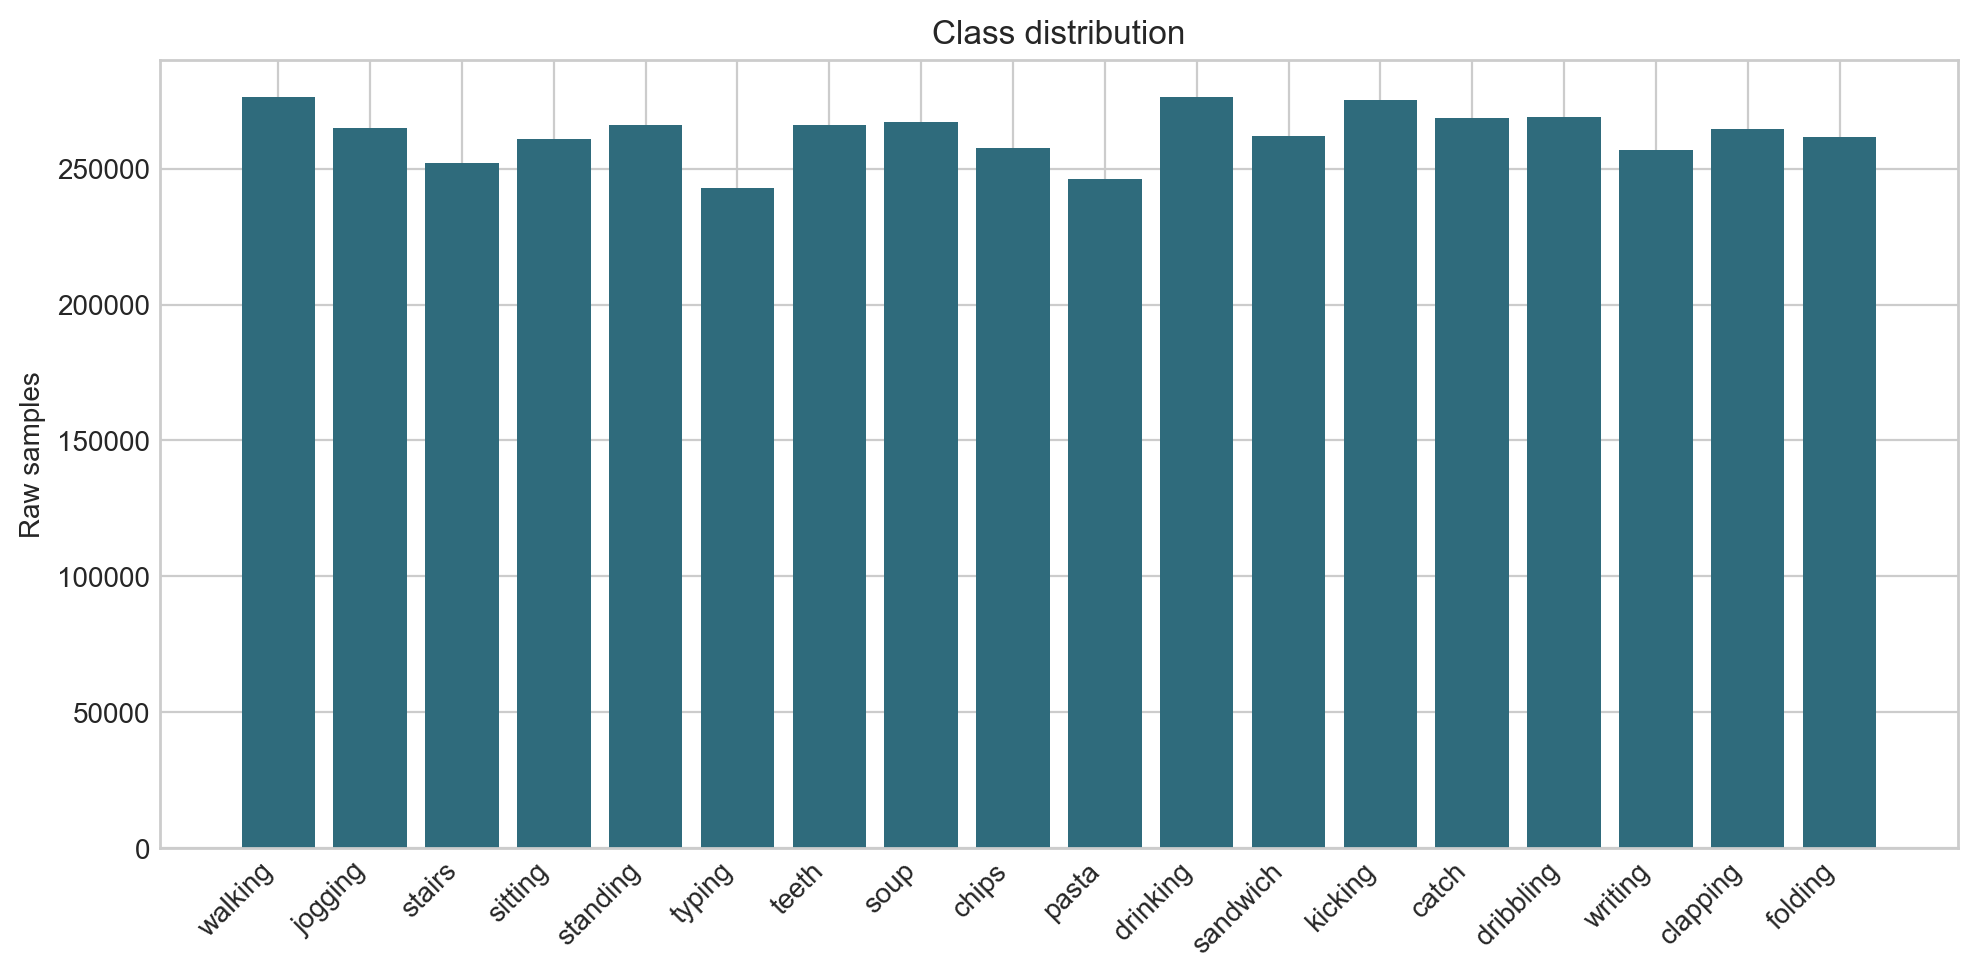

samples_per_subject.png


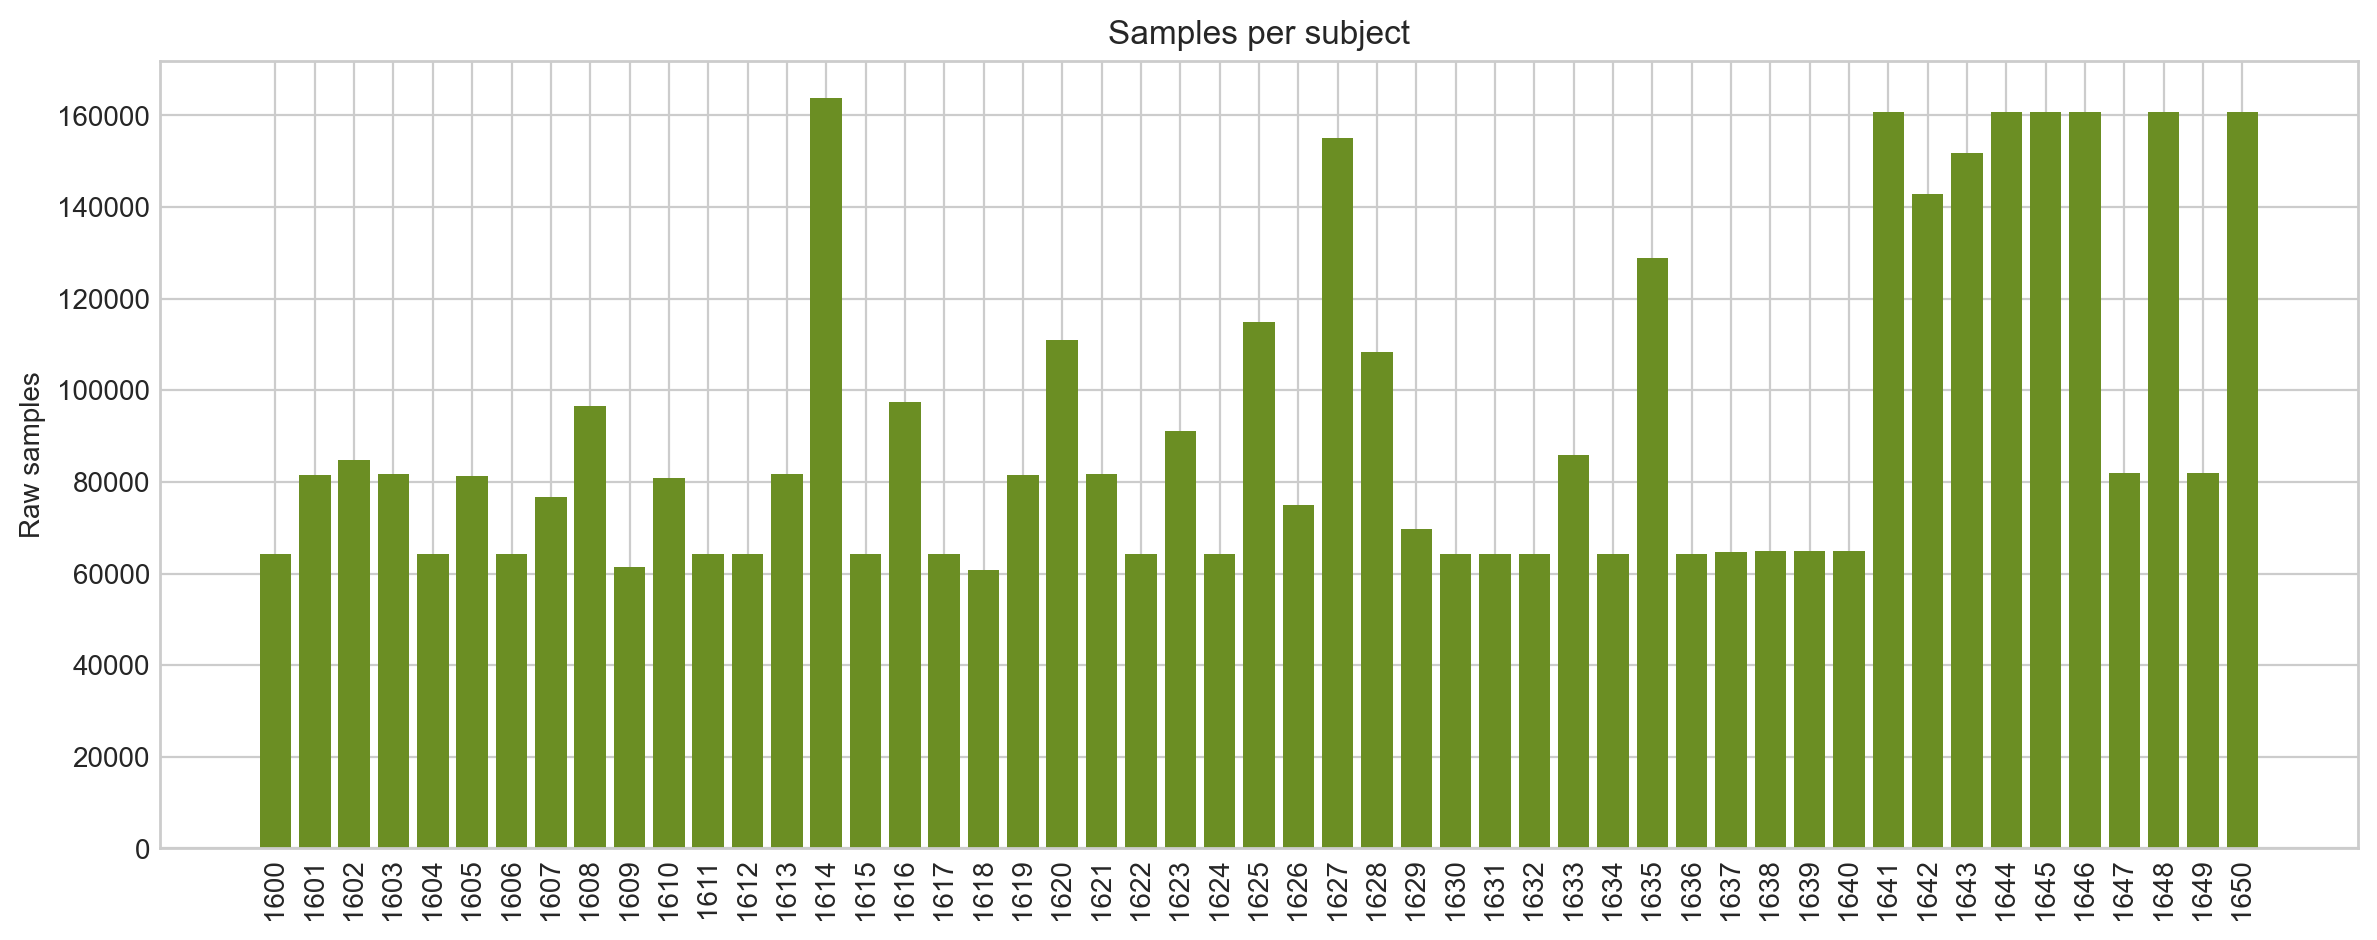

signal_examples.png


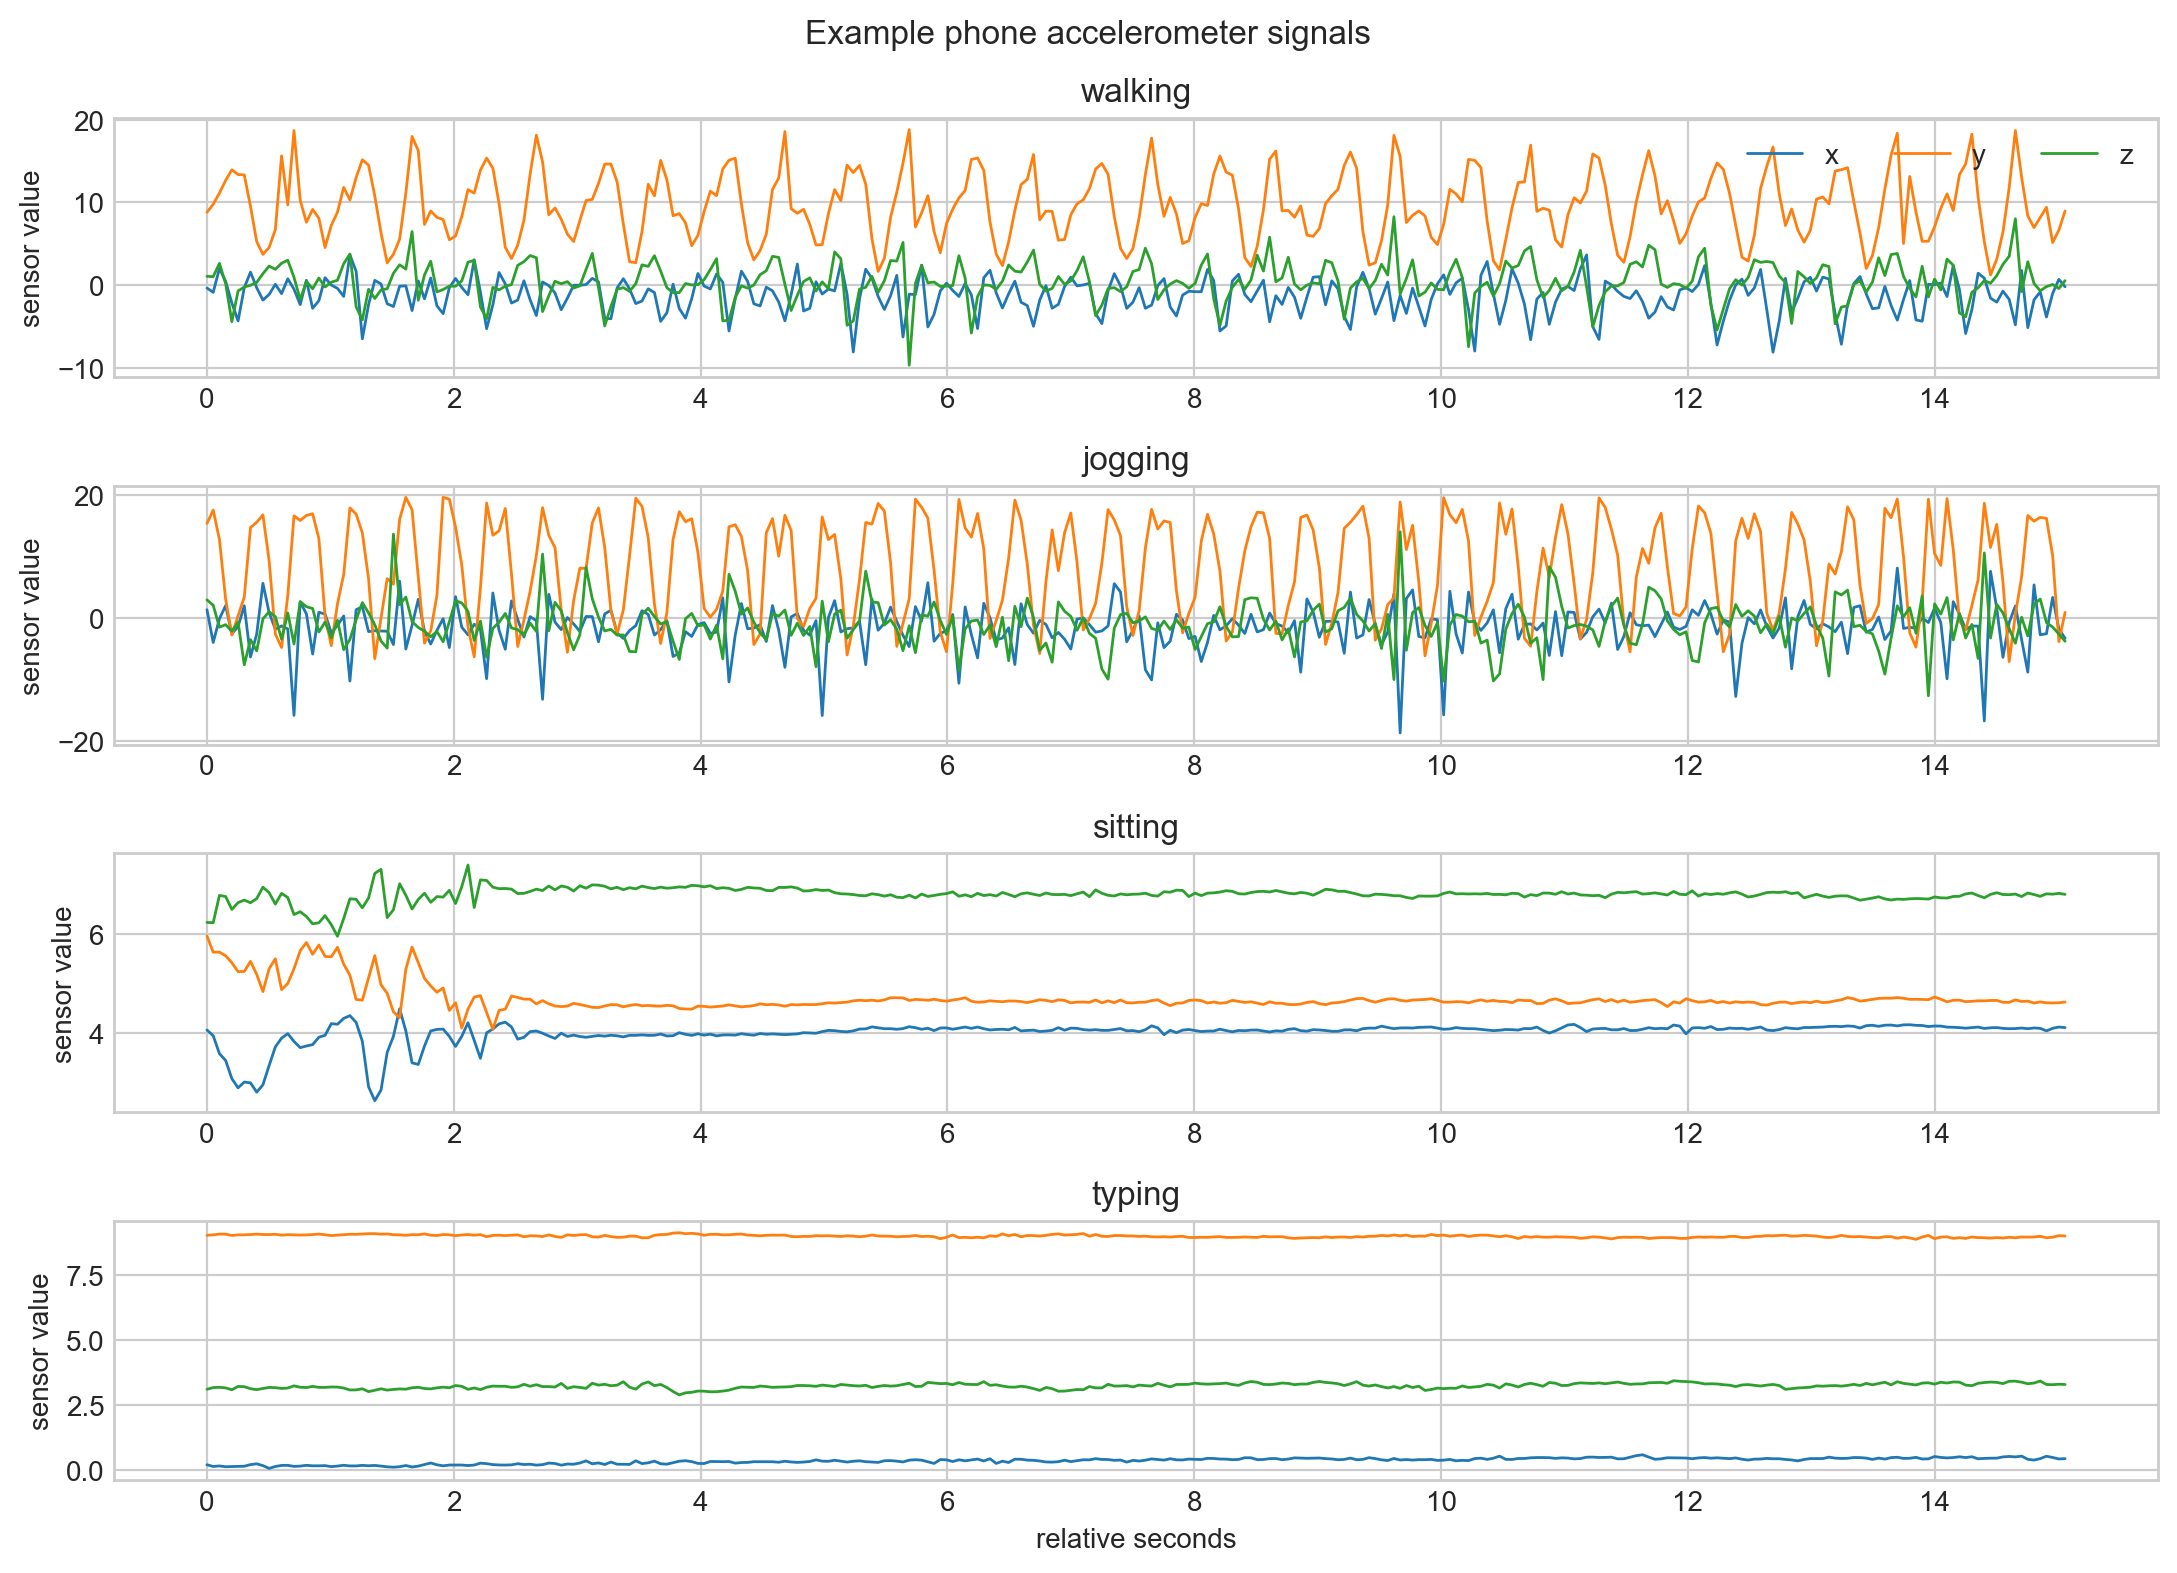

per_axis_means.png


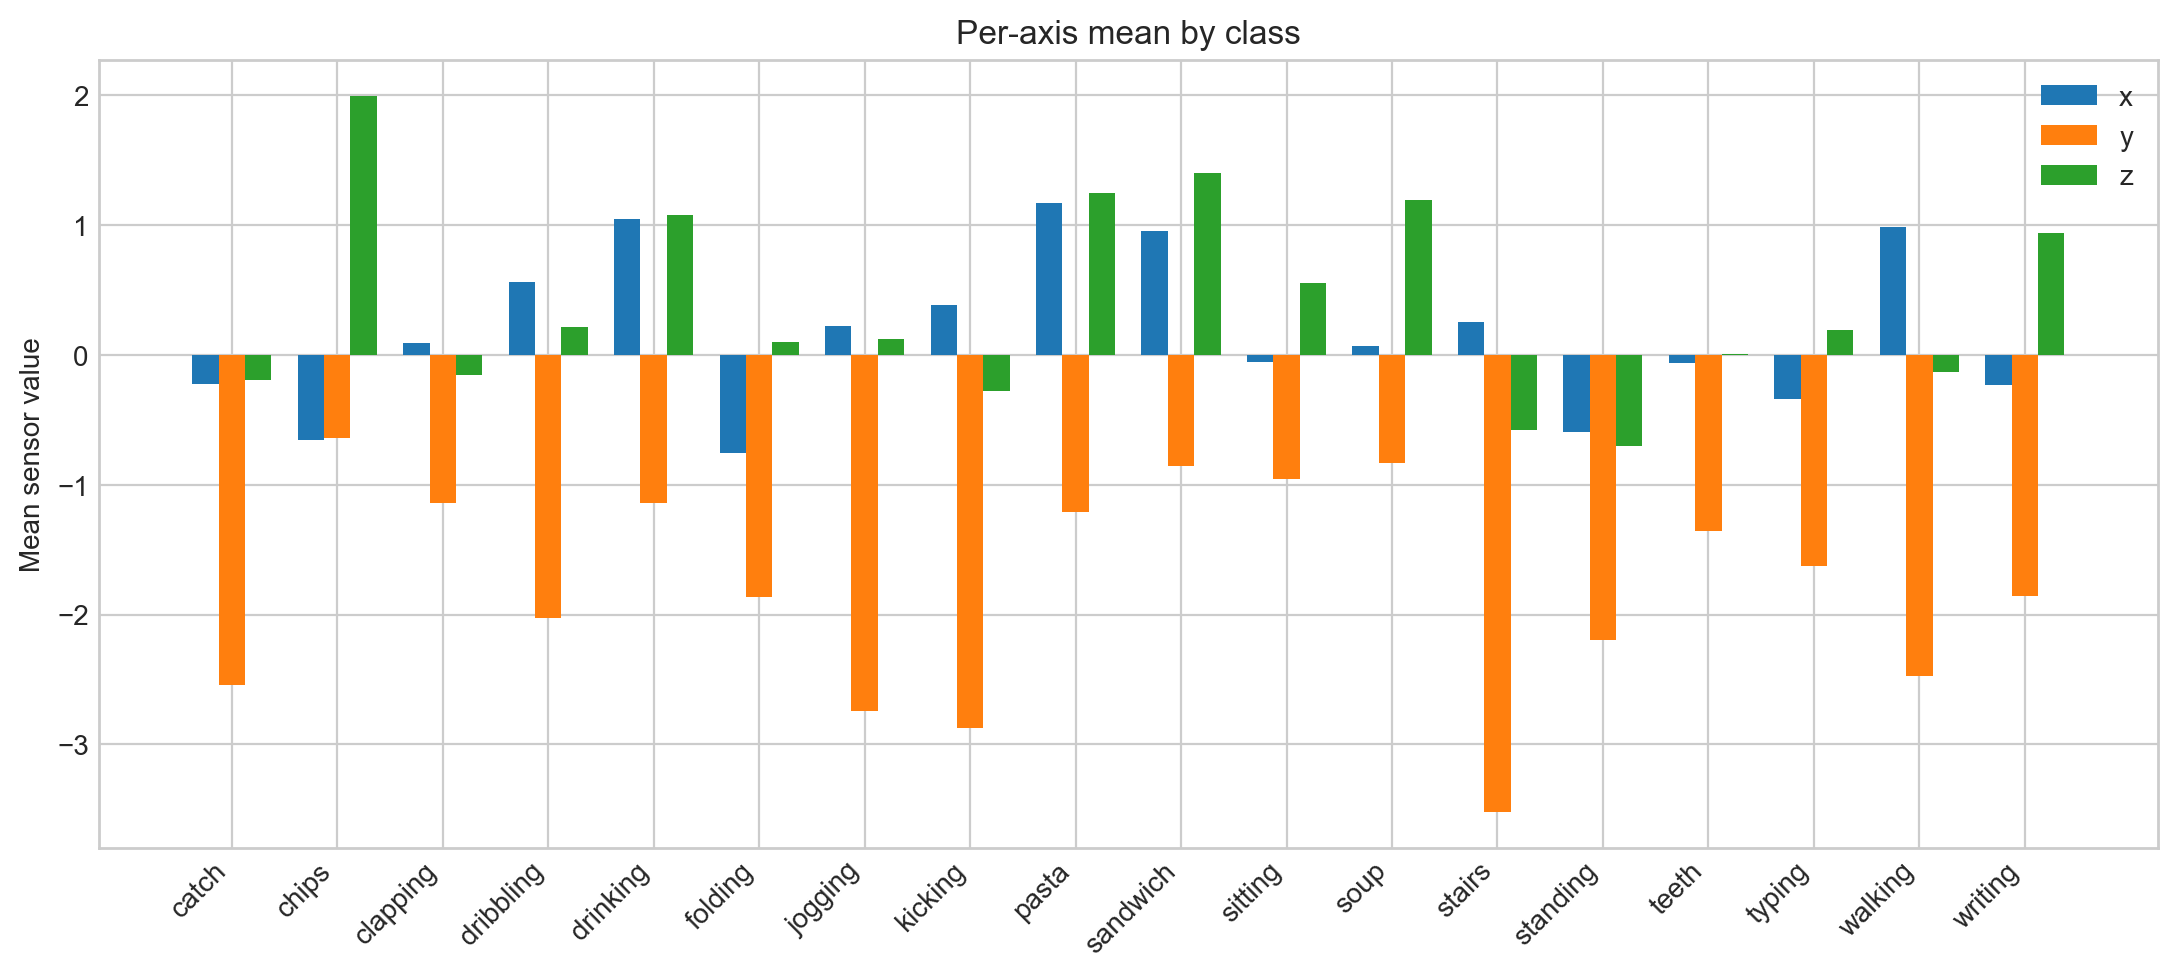

class_imbalance.png


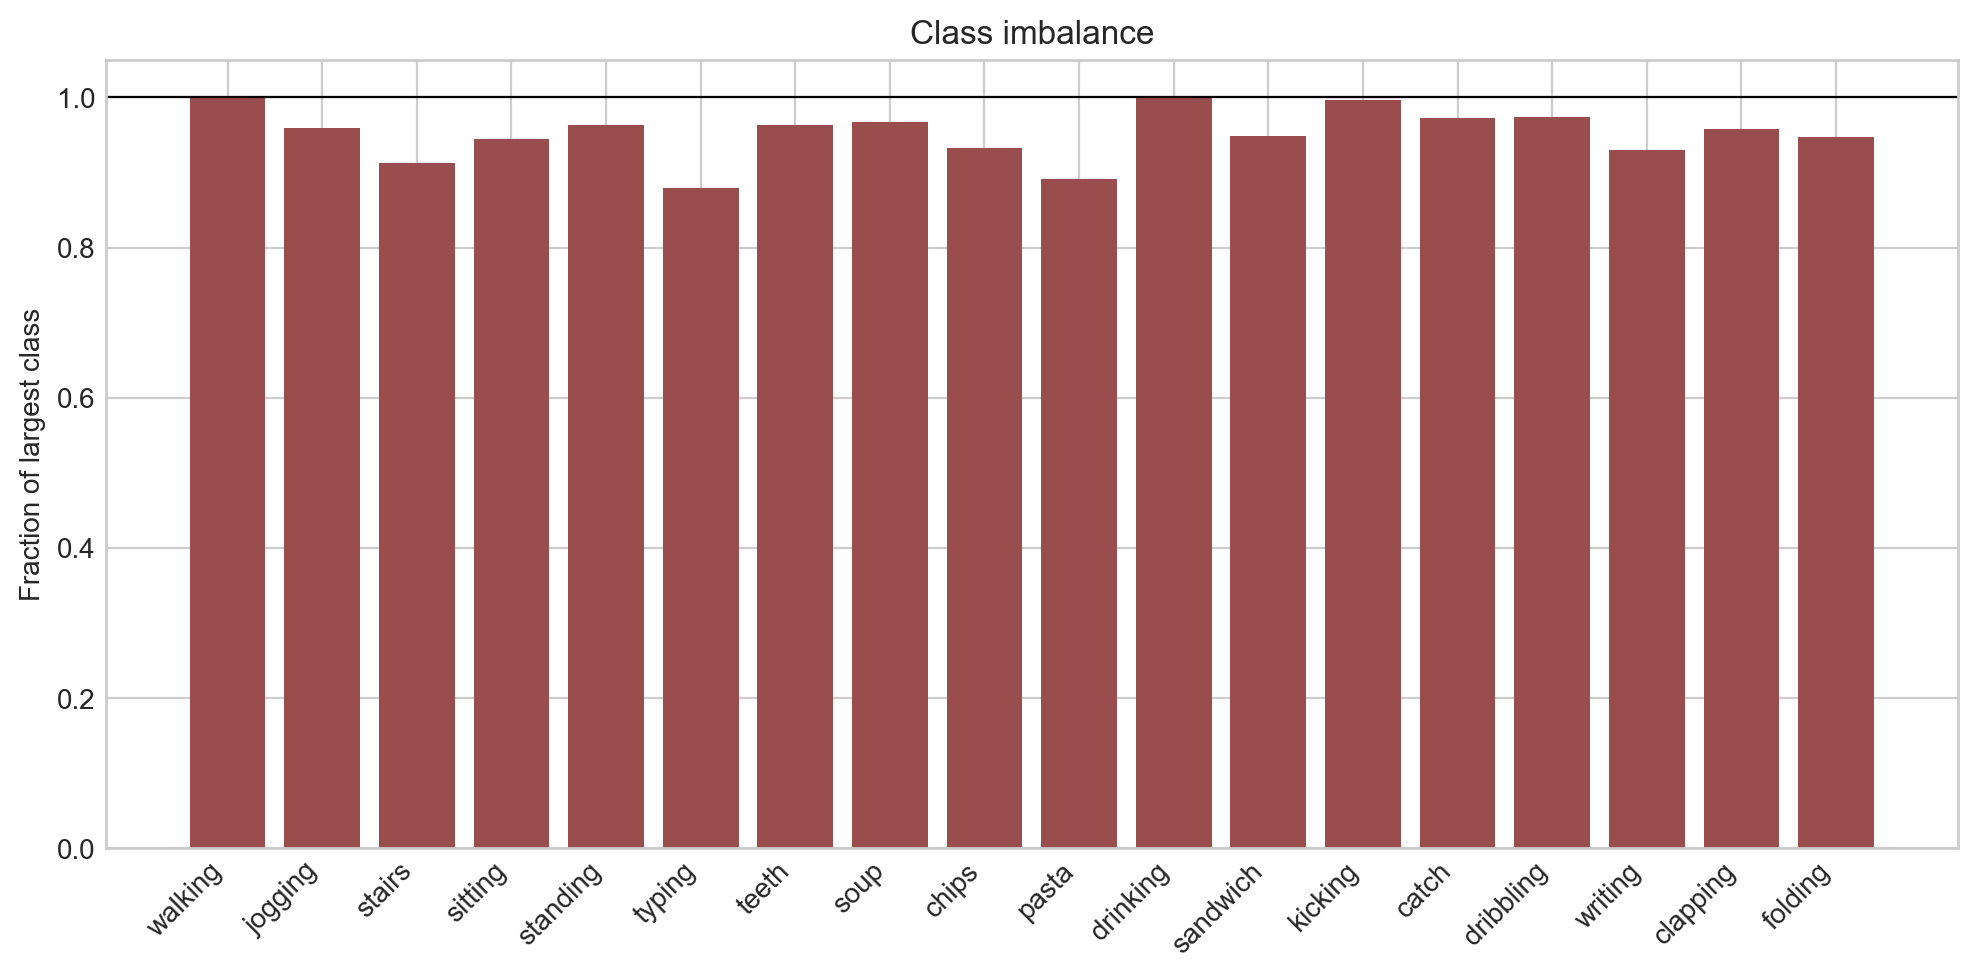

subject_activity_heatmap.png


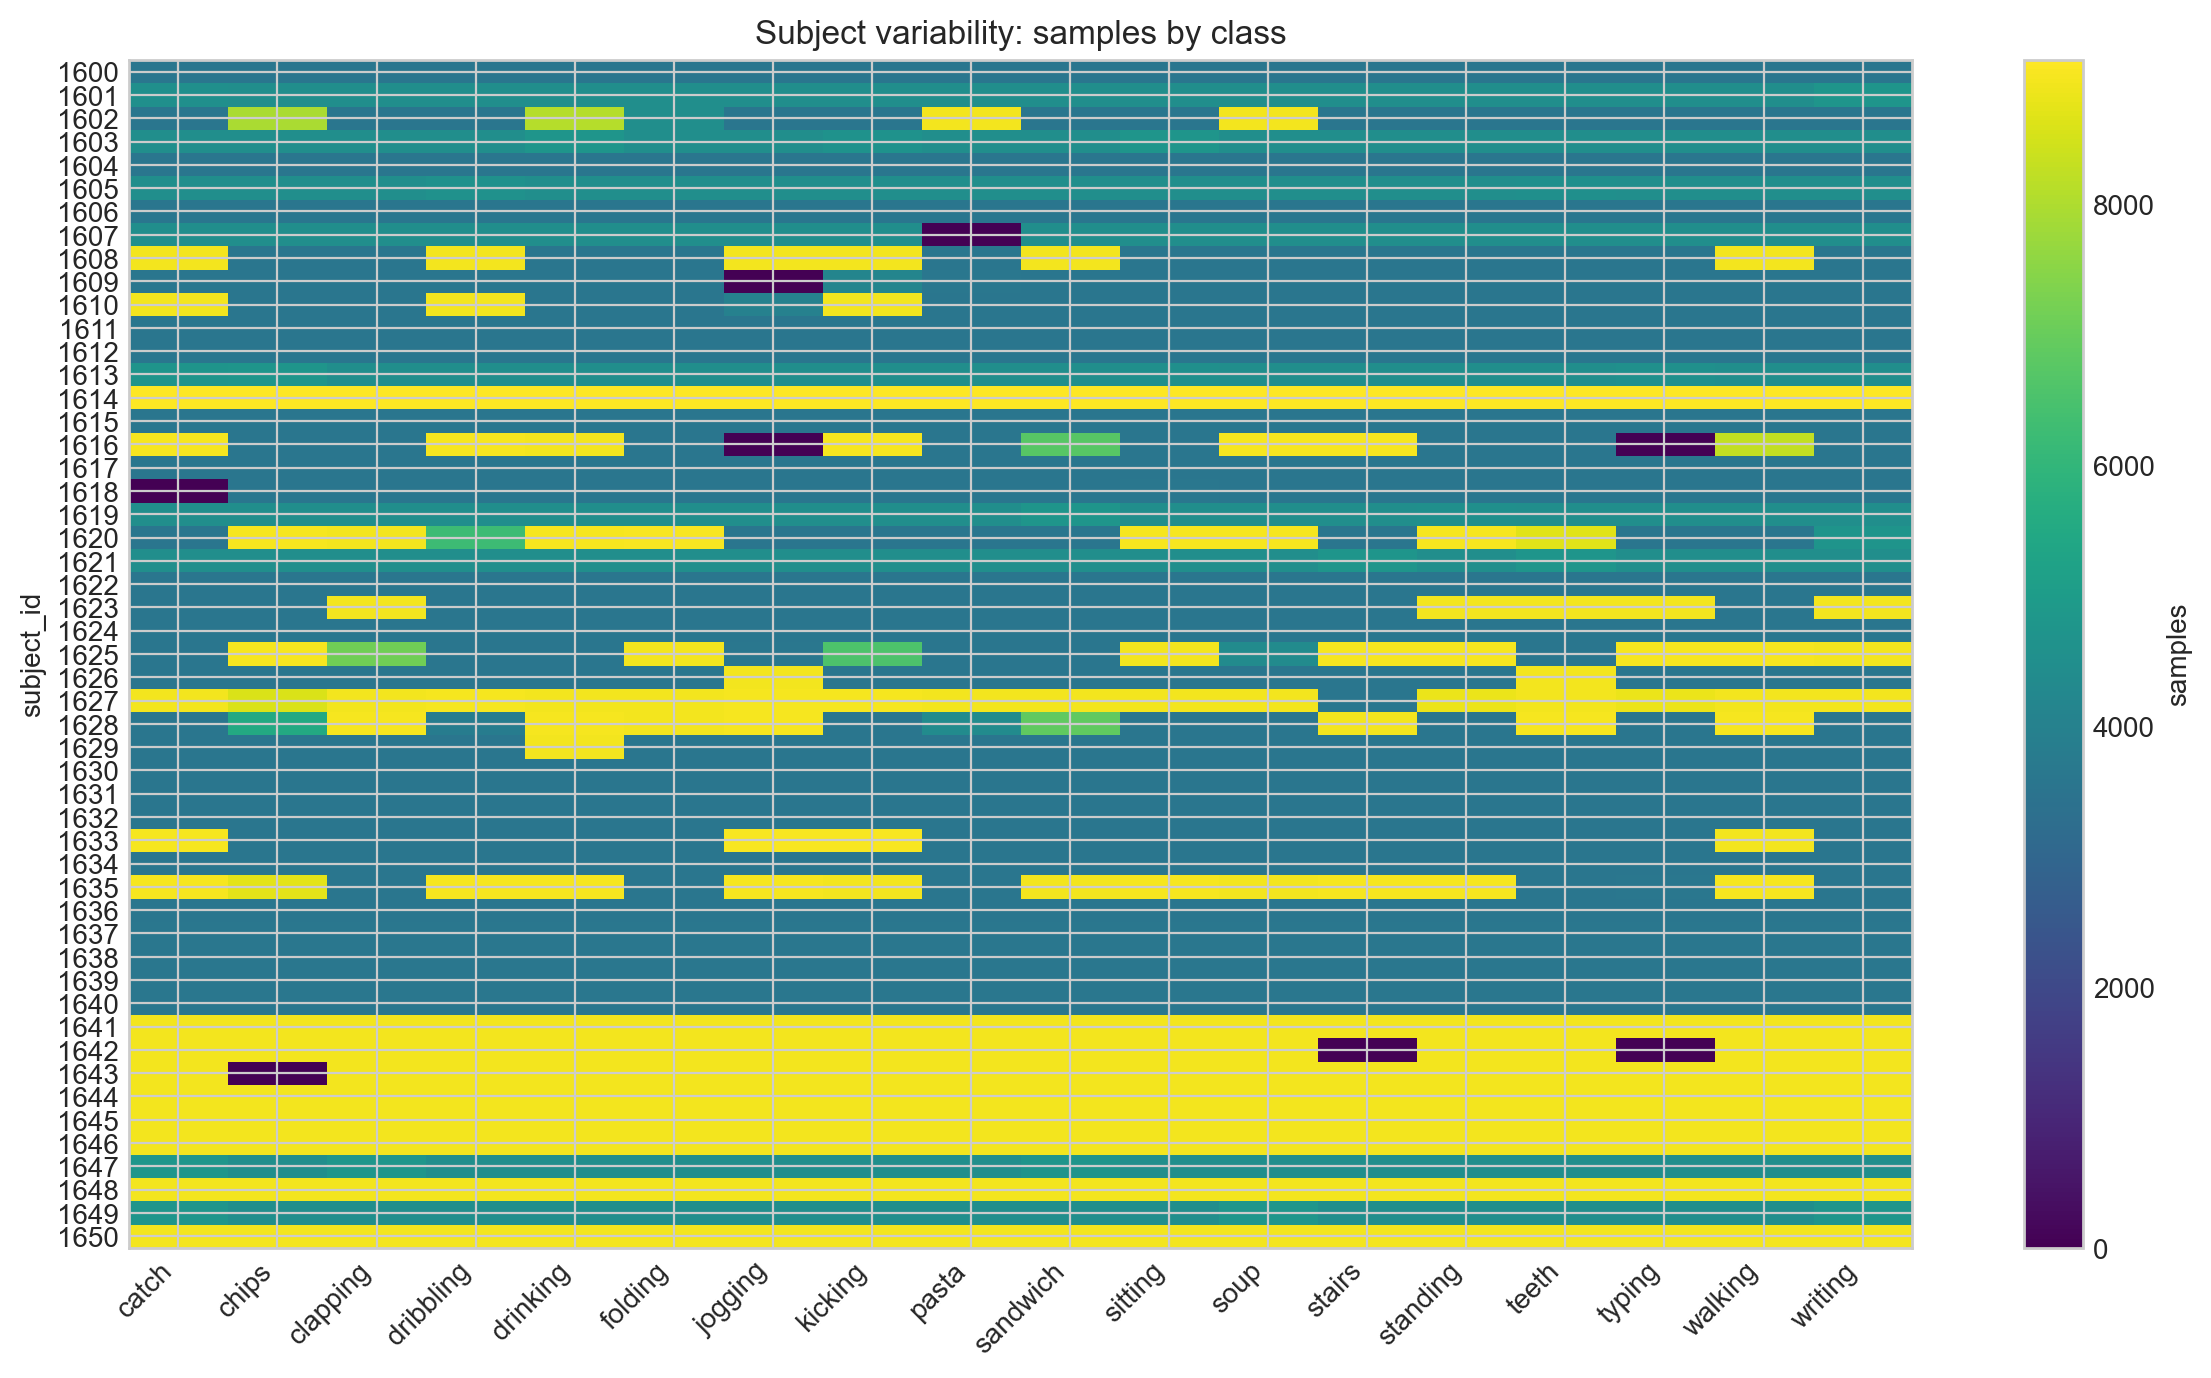

In [6]:
generate_figures(CLEAN_DATA, FIGURES_DIR, PROJECT_ROOT / "eda_summary.md")
for name in [
    "class_distribution.png",
    "samples_per_subject.png",
    "signal_examples.png",
    "per_axis_means.png",
    "class_imbalance.png",
    "subject_activity_heatmap.png",
]:
    print(name)
    display(Image(filename=str(FIGURES_DIR / name)))

## Per-axis Summary Statistics

In [7]:
axis_stats = df.groupby("activity_name", observed=True)[SENSOR_COLUMNS].agg(["mean", "std", "min", "max"])
axis_stats

x                                         y             \
                   mean       std        min        max      mean        std   
activity_name                                                                  
catch         -0.222211  4.634605 -33.422500  55.882990 -2.543052   8.344082   
chips         -0.651446  5.901679 -25.899742  24.960896 -0.642942   4.422065   
clapping       0.095554  5.990290 -24.668703  19.586964 -1.137783   5.016216   
dribbling      0.565438  5.368713 -24.989635  31.140045 -2.023128   8.096747   
drinking       1.047944  5.299500 -22.714367  19.080704 -1.141415   4.471046   
folding       -0.753123  5.109394 -43.886340  22.982609 -1.861053   7.518858   
jogging        0.223571  8.825976 -78.477610  78.477610 -2.744305  11.360630   
kicking        0.383352  5.268923 -39.814808  58.498356 -2.873954   8.325243   
pasta          1.171481  5.751496 -17.334020  20.836670 -1.206854   5.120545   
sandwich       0.952687  6.138577 -18.077255  25.882977 -0.856319   4.818478   
sitting       -0.052740  5.811274 -23.686745  19.612701 -0.952145   4.481072   
soup           0.069584  5.793985 -17.486038  16.396622 -0.834476   4.908642   
stairs         0.257547  5.816546 -33.453632  39.850730 -3.520692   7.929452   
standing      -0.590730  4.781519 -19.703842  19.612701 -2.198266   7.977858   
teeth         -0.064012  6.135158 -19.564926  19.156738 -1.356724   5.109473   
typing        -0.336267  5.897823 -19.749252  18.425179 -1.627545   4.964884   
walking        0.988529  6.194238 -40.593190  40.332130 -2.471911   8.773753   
writing       -0.235166  5.182506 -33.556620  17.421373 -1.854303   5.347951   

                                            z                                  
                     min        max      mean       std        min        max  
activity_name                                                                  
catch         -78.477610  64.411660 -0.191754  2.954513 -73.769000  61.726840  
chips         -25.863817  20.007994  1.996659  5.870081 -32.818954  19.593248  
clapping      -19.971981  17.561172 -0.154964  5.986340 -23.799310  19.593248  
dribbling     -37.187470  31.386732  0.214908  3.464585 -61.535240  43.646840  
drinking      -17.928980  16.967707  1.074364  6.606578 -19.334671  19.612701  
folding       -27.439740  19.302053  0.097975  3.093745 -65.534920  35.604362  
jogging       -78.477610  54.776493  0.119297  6.378122 -78.477610  69.081950  
kicking       -68.384995  51.674942 -0.274260  3.504277 -59.576115  63.087210  
pasta         -19.260748  17.799786  1.246394  5.601814 -26.752369  21.327650  
sandwich      -19.926193  26.951157  1.401180  5.456580 -21.720432  36.720440  
sitting       -19.956870  23.717880  0.554778  6.298208 -19.613300  20.558850  
soup          -15.971271  13.336487  1.194654  5.897670 -14.858978  16.313797  
stairs        -47.864468  52.352734 -0.581267  3.482551 -36.821033  28.409723  
standing      -19.956120  19.612701 -0.703201  1.705241 -21.835394  17.177673  
teeth         -19.923948  19.612701  0.008415  5.595537 -19.652512  17.705520  
typing        -19.971981  16.310500  0.195016  5.715304 -25.281828  19.612701  
walking       -37.688030  35.472637 -0.131457  3.913426 -61.480152  52.599422  
writing       -20.769610  19.612701  0.938008  5.868052 -21.241428  18.934510

## Data Quality Notes

- The class distribution is not perfectly balanced, so macro F1 is more informative than accuracy alone.
- Subject sample counts vary, which reinforces the subject-wise split strategy.
- Locomotion activities have visibly stronger periodic signals than hand/object activities, so per-class metrics should be inspected for harder low-amplitude classes.
- The raw timestamps are useful for ordering and gap checks, but they should not be interpreted as calendar datetimes.